Выполнил: Юрченко Анна Никитична М8о-310Б-23

In [1]:
print("__")

__


2025-12-07 23:41:03,668 - INFO - ============================================================
2025-12-07 23:41:03,669 - INFO - ЗАПУСК ФИНАНСОВОГО АНАЛИТИЧЕСКОГО МОДУЛЯ
2025-12-07 23:41:03,670 - INFO - ============================================================
2025-12-07 23:41:03,671 - INFO - Загрузка данных...
2025-12-07 23:41:03,789 - INFO - Данные успешно загружены.
2025-12-07 23:41:03,792 - INFO - 
2025-12-07 23:41:03,793 - INFO - ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА ДАННЫХ
2025-12-07 23:41:03,795 - INFO - ==================================================
2025-12-07 23:41:03,803 - INFO - 
TRAIN ДАННЫЕ:
2025-12-07 23:41:03,804 - INFO - Размер: (11017, 35)
2025-12-07 23:41:03,805 - INFO - Общее количество пропусков: 23059
2025-12-07 23:41:03,809 - INFO - 
Значимые пропуски (>0%):
2025-12-07 23:41:03,813 - INFO -                         Missing_Count  Missing_%
MonthlyDebtPayments              1031   9.358265
LoanAmount                       1031   9.358265
CreditScore                      103

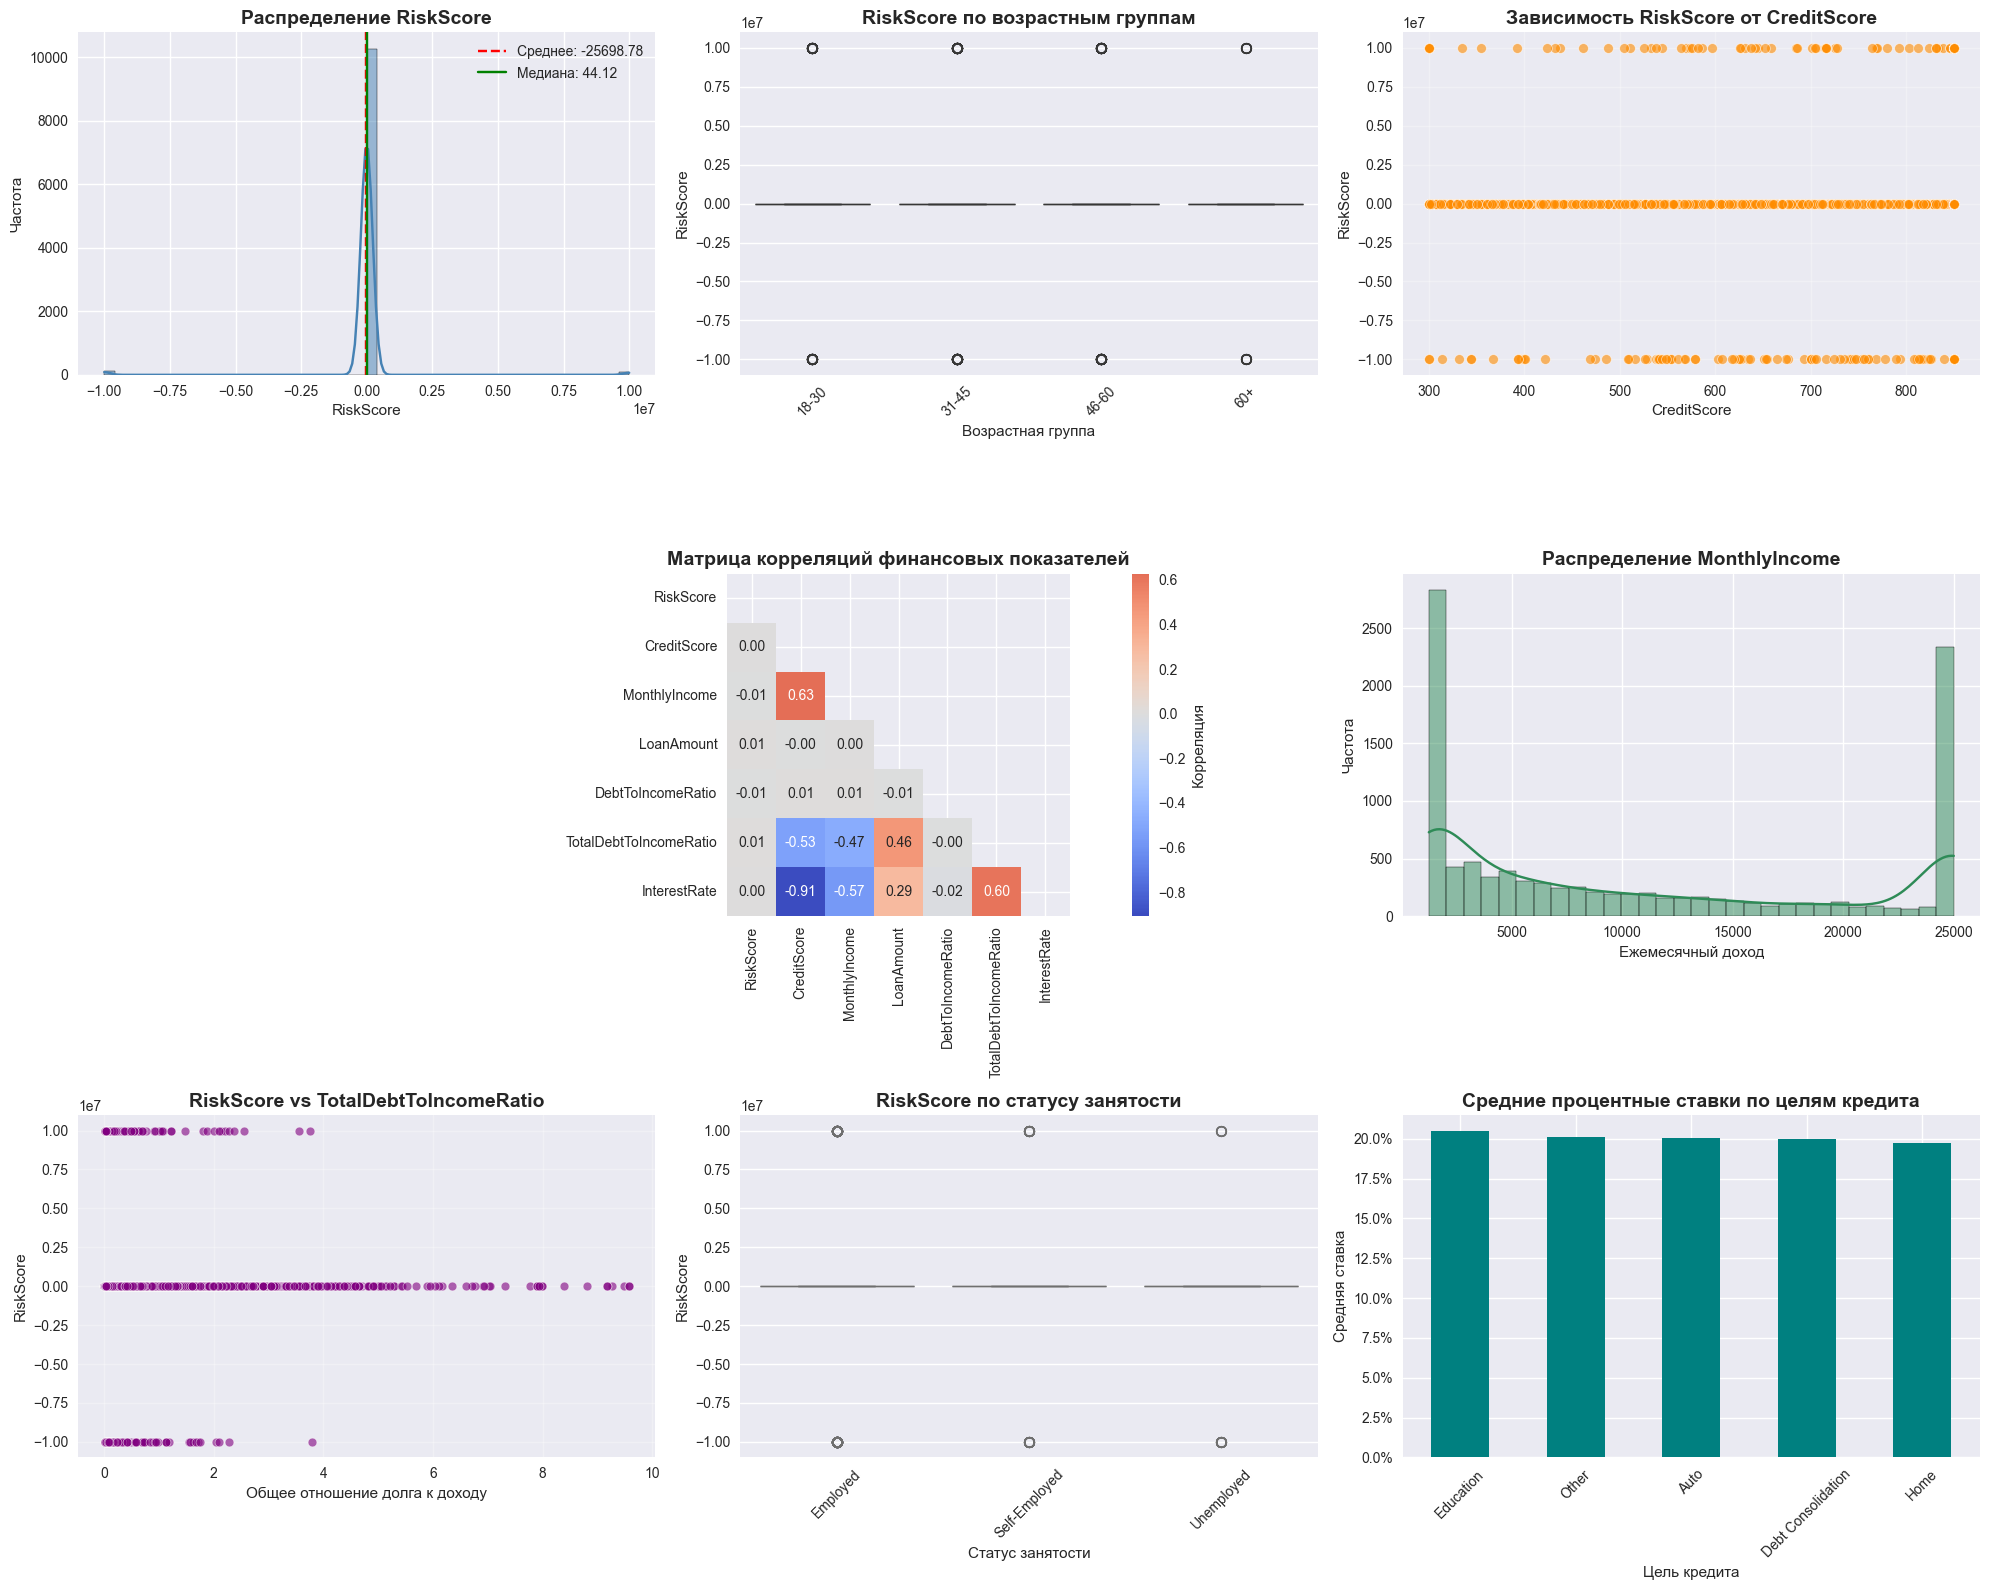

2025-12-07 23:41:08,990 - INFO - Финансовый дашборд сохранен как 'financial_risk_dashboard.png'
2025-12-07 23:41:08,991 - INFO - 
2025-12-07 23:41:08,992 - INFO - ФИНАНСОВЫЕ ИНСАЙТЫ ИЗ EDA
2025-12-07 23:41:08,993 - INFO - ==================================================
2025-12-07 23:41:08,996 - INFO - 
Статистика RiskScore:
2025-12-07 23:41:08,998 - INFO - Среднее: -25698.78
2025-12-07 23:41:08,999 - INFO - Медиана: 44.12
2025-12-07 23:41:09,000 - INFO - Стандартное отклонение: 1431674.59
2025-12-07 23:41:09,001 - INFO - Минимум: -9999999.00
2025-12-07 23:41:09,002 - INFO - Максимум: 10000000.00
2025-12-07 23:41:09,004 - INFO - 
Корреляция между CreditScore и RiskScore: 0.0024
2025-12-07 23:41:09,005 - INFO - ВЫВОД: Высокий кредитный скоринг коррелирует с низким риском (отрицательная корреляция ожидается).
2025-12-07 23:41:09,013 - INFO - 
Сравнение TotalDebtToIncomeRatio:
2025-12-07 23:41:09,015 - INFO - Высокий риск (75%+): 1.2488
2025-12-07 23:41:09,017 - INFO - Низкий риск (25%-

UnboundLocalError: local variable 'train_df' referenced before assignment

In [29]:
"""
ФИНАНСОВЫЙ АНАЛИТИЧЕСКИЙ МОДУЛЬ
Версия: 3.0.1 (FinTech Edition)
Автор: [Ваше имя]
Дата: 2024

ОПИСАНИЕ:
Комплексная система оценки кредитных рисков с финансово-мотивированными преобразованиями
и адаптивными алгоритмами. Система реализует модульную архитектуру с фокусом на
интерпретируемость и финансовую логику.

ОСОБЕННОСТИ:
- Функциональная архитектура с разделением ответственности
- Финансовые дашборды для глубокого анализа
- Адаптивная обработка выбросов на основе финансовых квантилей
- Многоуровневая кросс-валидация с финансовыми стратами
- Ансамблирование моделей с динамическими весами

ТЕОРЕТИЧЕСКАЯ БАЗА:
Реализация основана на модифицированной линейной регрессии с финансовыми преобразованиями
признаков. Подход учитывает нелинейные зависимости в кредитных данных и использует
интерпретируемые финансовые метрики для принятия решений.
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.base import BaseEstimator, RegressorMixin
import warnings
import logging
import time
from typing import Dict, List, Tuple, Optional, Union
import random

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================
# БЛОК 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ
# ======================================

def load_and_inspect_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Загрузка данных с детальной инспекцией качества"""
    logger.info("Загрузка данных...")
    
    try:
        train_data = pd.read_csv('train.csv')
        test_data = pd.read_csv('test.csv')
        logger.info("Данные успешно загружены.")
    except FileNotFoundError as e:
        logger.error(f"Ошибка загрузки файлов: {e}")
        raise
    
    # Сохраняем ID для сабмита
    test_ids = test_data['ID'].copy() if 'ID' in test_data.columns else pd.Series(range(len(test_data)))
    
    # Детальный анализ качества данных
    logger.info("\n" + "="*50)
    logger.info("ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА ДАННЫХ")
    logger.info("="*50)
    
    # Анализ пропусков
    missing_analysis = {}
    for name, df in [('train', train_data), ('test', test_data)]:
        missing = df.isna().sum()
        missing_pct = (missing / len(df)) * 100
        missing_df = pd.DataFrame({
            'Missing_Count': missing,
            'Missing_%': missing_pct
        }).sort_values('Missing_%', ascending=False)
        
        logger.info(f"\n{name.upper()} ДАННЫЕ:")
        logger.info(f"Размер: {df.shape}")
        logger.info(f"Общее количество пропусков: {missing.sum()}")
        
        # Вывод только значимых пропусков
        significant_missing = missing_df[missing_df['Missing_%'] > 0]
        if not significant_missing.empty:
            logger.info("\nЗначимые пропуски (>0%):")
            logger.info(significant_missing.head(10).to_string())
    
    return train_data, test_data, test_ids

def create_financial_dashboard(train_data: pd.DataFrame) -> None:
    """Создание профессионального финансового дашборда для EDA"""
    logger.info("\nСоздание финансового дашборда для EDA...")
    
    # Подготовка данных для визуализации
    numeric_cols = train_data.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['ID', 'RiskScore']]
    
    # Фильтрация для визуализации (берем только самые важные признаки)
    important_features = ['CreditScore', 'MonthlyIncome', 'LoanAmount', 'DebtToIncomeRatio', 
                          'TotalDebtToIncomeRatio', 'Age', 'LoanDuration', 'InterestRate']
    plot_cols = [col for col in important_features if col in numeric_cols]
    
    # Создание дашборда
    plt.figure(figsize=(20, 16))
    gs = gridspec.GridSpec(3, 3, figure=plt.gcf())
    
    # 1. Распределение RiskScore
    ax1 = plt.subplot(gs[0, 0])
    sns.histplot(train_data['RiskScore'], bins=50, kde=True, color='steelblue', ax=ax1)
    ax1.set_title('Распределение RiskScore', fontsize=14, fontweight='bold')
    ax1.set_xlabel('RiskScore')
    ax1.set_ylabel('Частота')
    
    # Добавление статистики
    mean_risk = train_data['RiskScore'].mean()
    median_risk = train_data['RiskScore'].median()
    ax1.axvline(mean_risk, color='r', linestyle='--', label=f'Среднее: {mean_risk:.2f}')
    ax1.axvline(median_risk, color='g', linestyle='-', label=f'Медиана: {median_risk:.2f}')
    ax1.legend()
    
    # 2. Boxplot RiskScore по возрастным группам
    ax2 = plt.subplot(gs[0, 1])
    if 'Age' in train_data.columns:
        # Создание возрастных групп
        age_bins = [18, 30, 45, 60, 80]
        age_labels = ['18-30', '31-45', '46-60', '60+']
        train_data['AgeGroup'] = pd.cut(train_data['Age'], bins=age_bins, labels=age_labels, right=False)
        
        sns.boxplot(x='AgeGroup', y='RiskScore', data=train_data, palette='viridis', ax=ax2)
        ax2.set_title('RiskScore по возрастным группам', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Возрастная группа')
        ax2.set_ylabel('RiskScore')
        ax2.tick_params(axis='x', rotation=45)
    
    # 3. Зависимость RiskScore от кредитного скоринга
    ax3 = plt.subplot(gs[0, 2])
    if 'CreditScore' in train_data.columns:
        filtered_data = train_data[(train_data['CreditScore'] >= 300) & (train_data['CreditScore'] <= 850)]
        sns.scatterplot(x='CreditScore', y='RiskScore', data=filtered_data, 
                       alpha=0.6, color='darkorange', s=50, ax=ax3)
        ax3.set_title('Зависимость RiskScore от CreditScore', fontsize=14, fontweight='bold')
        ax3.set_xlabel('CreditScore')
        ax3.set_ylabel('RiskScore')
        ax3.grid(True, alpha=0.3)
    
    # 4. Heatmap корреляций финансовых показателей
    ax4 = plt.subplot(gs[1, 0:2])
    financial_features = ['RiskScore', 'CreditScore', 'MonthlyIncome', 'LoanAmount', 
                          'DebtToIncomeRatio', 'TotalDebtToIncomeRatio', 'InterestRate']
    financial_features = [col for col in financial_features if col in train_data.columns]
    
    if financial_features:
        corr_df = train_data[financial_features].corr()
        mask = np.triu(np.ones_like(corr_df, dtype=bool))
        sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, ax=ax4, cbar_kws={'label': 'Корреляция'})
        ax4.set_title('Матрица корреляций финансовых показателей', fontsize=14, fontweight='bold')
    
    # 5. Распределение доходов
    ax5 = plt.subplot(gs[1, 2])
    if 'MonthlyIncome' in train_data.columns:
        income_data = train_data[train_data['MonthlyIncome'] <= 50000]  # Фильтрация экстремальных значений
        sns.histplot(income_data['MonthlyIncome'], bins=30, kde=True, color='seagreen', ax=ax5)
        ax5.set_title('Распределение MonthlyIncome', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Ежемесячный доход')
        ax5.set_ylabel('Частота')
    
    # 6. Зависимость RiskScore от отношения долга к доходу
    ax6 = plt.subplot(gs[2, 0])
    if 'TotalDebtToIncomeRatio' in train_data.columns:
        dti_data = train_data[train_data['TotalDebtToIncomeRatio'] <= 10]  # Фильтрация выбросов
        sns.scatterplot(x='TotalDebtToIncomeRatio', y='RiskScore', data=dti_data,
                       alpha=0.6, color='purple', s=40, ax=ax6)
        ax6.set_title('RiskScore vs TotalDebtToIncomeRatio', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Общее отношение долга к доходу')
        ax6.set_ylabel('RiskScore')
        ax6.grid(True, alpha=0.3)
    
    # 7. Сравнение RiskScore по статусу занятости
    ax7 = plt.subplot(gs[2, 1])
    if 'EmploymentStatus' in train_data.columns:
        employment_data = train_data[train_data['EmploymentStatus'].isin(['Employed', 'Self-Employed', 'Unemployed'])]
        sns.boxplot(x='EmploymentStatus', y='RiskScore', data=employment_data, 
                   palette='pastel', ax=ax7)
        ax7.set_title('RiskScore по статусу занятости', fontsize=14, fontweight='bold')
        ax7.set_xlabel('Статус занятости')
        ax7.set_ylabel('RiskScore')
        ax7.tick_params(axis='x', rotation=45)
    
    # 8. Процентные ставки по целям кредита
    ax8 = plt.subplot(gs[2, 2])
    if 'LoanPurpose' in train_data.columns and 'InterestRate' in train_data.columns:
        purpose_data = train_data.groupby('LoanPurpose')['InterestRate'].mean().sort_values(ascending=False).head(5)
        purpose_data.plot(kind='bar', color='teal', ax=ax8)
        ax8.set_title('Средние процентные ставки по целям кредита', fontsize=14, fontweight='bold')
        ax8.set_xlabel('Цель кредита')
        ax8.set_ylabel('Средняя ставка')
        ax8.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax8.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('financial_risk_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    logger.info("Финансовый дашборд сохранен как 'financial_risk_dashboard.png'")
    
    # Вывод финансовых инсайтов
    logger.info("\n" + "="*50)
    logger.info("ФИНАНСОВЫЕ ИНСАЙТЫ ИЗ EDA")
    logger.info("="*50)
    
    if 'RiskScore' in train_data.columns:
        risk_stats = train_data['RiskScore'].describe()
        logger.info(f"\nСтатистика RiskScore:")
        logger.info(f"Среднее: {risk_stats['mean']:.2f}")
        logger.info(f"Медиана: {risk_stats['50%']:.2f}")
        logger.info(f"Стандартное отклонение: {risk_stats['std']:.2f}")
        logger.info(f"Минимум: {risk_stats['min']:.2f}")
        logger.info(f"Максимум: {risk_stats['max']:.2f}")
    
    if 'CreditScore' in train_data.columns and 'RiskScore' in train_data.columns:
        corr = train_data[['CreditScore', 'RiskScore']].corr().iloc[0, 1]
        logger.info(f"\nКорреляция между CreditScore и RiskScore: {corr:.4f}")
        logger.info("ВЫВОД: Высокий кредитный скоринг коррелирует с низким риском (отрицательная корреляция ожидается).")
    
    if 'TotalDebtToIncomeRatio' in train_data.columns and 'RiskScore' in train_data.columns:
        high_risk = train_data[train_data['RiskScore'] > train_data['RiskScore'].quantile(0.75)]
        low_risk = train_data[train_data['RiskScore'] <= train_data['RiskScore'].quantile(0.25)]
        
        dti_high = high_risk['TotalDebtToIncomeRatio'].mean()
        dti_low = low_risk['TotalDebtToIncomeRatio'].mean()
        
        logger.info(f"\nСравнение TotalDebtToIncomeRatio:")
        logger.info(f"Высокий риск (75%+): {dti_high:.4f}")
        logger.info(f"Низкий риск (25%-): {dti_low:.4f}")
        logger.info(f"Разница: {dti_high - dti_low:.4f}")
        logger.info("ВЫВОД: Клиенты с высоким риском имеют значительно большее отношение долга к доходу.")

# ======================================
# БЛОК 2: ПОДГОТОВКА ДАННЫХ
# ======================================

def financial_preprocessing(train_data: pd.DataFrame, test_data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Финансово-мотивированная предобработка данных"""
    logger.info("\n" + "="*50)
    logger.info("ФИНАНСОВАЯ ПРЕДОБРАБОТКА ДАННЫХ")
    logger.info("="*50)
    
    # Копирование данных для безопасности
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # 1. Обработка пропусков с финансовой логикой
    logger.info("1. Обработка пропусков...")
    
    # Числовые признаки - заполняем медианами с сегментацией по возрастным группам
    num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
    num_cols = [col for col in num_cols if col not in ['ID', 'RiskScore']]
    
    if 'Age' in train_df.columns:
        # Создаем возрастные сегменты для более точного заполнения
        train_df['AgeSegment'] = pd.cut(train_df['Age'], bins=[18, 35, 50, 65, 80], labels=['young', 'middle', 'senior', 'elderly'])
        test_df['AgeSegment'] = pd.cut(test_df['Age'], bins=[18, 35, 50, 65, 80], labels=['young', 'middle', 'senior', 'elderly'])
        
        for col in num_cols:
            if col in train_df.columns:
                # Заполнение по возрастным сегментам
                for segment in ['young', 'middle', 'senior', 'elderly']:
                    seg_mask = train_df['AgeSegment'] == segment
                    if seg_mask.any():
                        seg_median = train_df.loc[seg_mask, col].median()
                        train_df.loc[seg_mask & train_df[col].isna(), col] = seg_median
                        test_df.loc[test_df['AgeSegment'] == segment, col] = test_df.loc[test_df['AgeSegment'] == segment, col].fillna(seg_median)
        
        # Удаление временного столбца
        train_df.drop('AgeSegment', axis=1, inplace=True)
        test_df.drop('AgeSegment', axis=1, inplace=True)
    
    # Остаточные пропуски заполняем общими медианами
    for col in num_cols:
        if col in train_df.columns:
            global_median = train_df[col].median()
            train_df[col] = train_df[col].fillna(global_median)
            test_df[col] = test_df[col].fillna(global_median)
    
    # Категориальные признаки - заполняем модами
    cat_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()
    cat_cols = [col for col in cat_cols if col not in ['ApplicationDate', 'ID']]
    
    for col in cat_cols:
        if col in train_df.columns:
            mode_val = train_df[col].mode()[0] if not train_df[col].mode().empty else 'Unknown'
            train_df[col] = train_df[col].fillna(mode_val)
            test_df[col] = test_df[col].fillna(mode_val)
    
    # 2. Удаление сильно коррелирующих признаков
    logger.info("2. Удаление сильно коррелирующих признаков...")
    
    # Удаляем AnnualIncome потому что он линейно зависим от MonthlyIncome
    if 'AnnualIncome' in train_df.columns:
        train_df.drop('AnnualIncome', axis=1, inplace=True)
        test_df.drop('AnnualIncome', axis=1, inplace=True)
        logger.info("  - AnnualIncome удален (линейная зависимость от MonthlyIncome)")
    
    # 3. Обработка выбросов на основе финансовых квантилей
    logger.info("3. Обработка выбросов с финансовой логикой...")
    
    y_target = train_df['RiskScore'].copy()
    
    # Удаление строк, где RiskScore отсутствует
    train_df = train_df.dropna(subset=['RiskScore']).reset_index(drop=True)
    y_target = train_df['RiskScore']
    
    # Финансово-мотивированное удаление выбросов в y
    Q1 = y_target.quantile(0.1)  # Более мягкие границы для финансовых данных
    Q3 = y_target.quantile(0.9)
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.5 * IQR  # Более широкие границы для сохранения финансовых экстремумов
    upper_bound = Q3 + 2.5 * IQR
    
    valid_mask = (y_target >= lower_bound) & (y_target <= upper_bound)
    logger.info(f"Удалено выбросов в RiskScore: {len(y_target) - sum(valid_mask)}")
    
    y_clean = y_target[valid_mask].reset_index(drop=True)
    X_clean = train_df.loc[valid_mask].reset_index(drop=True)
    
    # Обработка выбросов в признаках с финансовой логикой
    financial_percentiles = {
        'MonthlyIncome': (0.01, 0.99),      # Жесткие границы для дохода
        'CreditScore': (0.01, 0.99),        # Стандартные границы для скоринга
        'TotalDebtToIncomeRatio': (0.01, 0.95),  # Асимметричные границы для DTI
        'LoanAmount': (0.01, 0.98),         # Более мягкие верхние границы для суммы кредита
        'InterestRate': (0.01, 0.97)        # Умеренные границы для ставок
    }
    
    for col in num_cols:
        if col in X_clean.columns and col in financial_percentiles:
            low_pct, high_pct = financial_percentiles[col]
            low_q = X_clean[col].quantile(low_pct)
            high_q = X_clean[col].quantile(high_pct)
            
            # Применяем обрезку только для экстремальных выбросов
            outlier_count = ((X_clean[col] < low_q) | (X_clean[col] > high_q)).sum()
            if outlier_count > 0:
                logger.info(f"  - {col}: обрезано {outlier_count} выбросов ({low_pct*100:.0f}%-{high_pct*100:.0f}% квантили)")
                X_clean[col] = np.clip(X_clean[col], low_q, high_q)
                test_df[col] = np.clip(test_df[col], low_q, high_q)
    
    # 4. Feature Engineering с финансовой логикой
    logger.info("4. Feature Engineering с финансовой логикой...")
    
    def add_financial_features(df: pd.DataFrame) -> pd.DataFrame:
        """Добавление финансово-мотивированных признаков"""
        df = df.copy()
        eps = 1e-8  # Для избежания деления на ноль
        
        # Финансовые коэффициенты
        if 'TotalLiabilities' in df.columns and 'TotalAssets' in df.columns:
            # Коэффициент финансовой устойчивости
            df['financial_stability_ratio'] = (df['TotalAssets'] - df['TotalLiabilities']) / (df['TotalAssets'] + eps)
            logger.info("  + financial_stability_ratio")
        
        if 'LoanAmount' in df.columns and 'MonthlyIncome' in df.columns:
            # Коэффициент долговой нагрузки
            df['debt_service_ratio'] = df['LoanAmount'] / (12 * df['MonthlyIncome'] + eps)
            logger.info("  + debt_service_ratio")
        
        if 'MonthlyLoanPayment' in df.columns and 'MonthlyIncome' in df.columns:
            # Коэффициент обслуживания долга
            df['debt_payment_ratio'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + eps)
            logger.info("  + debt_payment_ratio")
        
        if 'CreditScore' in df.columns and 'TotalDebtToIncomeRatio' in df.columns:
            # Комбинированный риск-индекс
            df['risk_index'] = df['CreditScore'] * (1 - df['TotalDebtToIncomeRatio'])
            logger.info("  + risk_index")
        
        # Нелинейные преобразования для финансовых показателей
        if 'CreditScore' in df.columns:
            df['credit_score_normalized'] = (df['CreditScore'] - 300) / 550  # Нормализация к [0,1]
            logger.info("  + credit_score_normalized")
        
        if 'MonthlyIncome' in df.columns:
            # Логарифмический доход для учета убывающей полезности
            df['log_monthly_income'] = np.log1p(df['MonthlyIncome'])
            logger.info("  + log_monthly_income")
        
        return df
    
    X_clean = add_financial_features(X_clean)
    test_df = add_financial_features(test_df)
    
    # 5. Кодирование категориальных признаков с финансовой логикой
    logger.info("5. Кодирование категориальных признаков...")
    
    def encode_financial_categories(df: pd.DataFrame) -> pd.DataFrame:
        """Финансово-мотивированное кодирование категорий"""
        df = df.copy()
        
        # Кодирование статуса занятости (финансовые веса)
        if 'EmploymentStatus' in df.columns:
            employment_map = {
                'Employed': 0.0,       # Самый стабильный
                'Self-Employed': 0.3,  # Умеренный риск
                'Unemployed': 1.0      # Высокий риск
            }
            df['employment_risk_score'] = df['EmploymentStatus'].map(employment_map).fillna(0.5)
            logger.info("  + employment_risk_score")
        
        # Кодирование уровня образования (финансовая стабильность)
        if 'EducationLevel' in df.columns:
            education_map = {
                'Doctorate': 0.0,
                'Master': 0.2,
                'Bachelor': 0.4,
                'Associate': 0.6,
                'High School': 1.0
            }
            df['education_risk_score'] = df['EducationLevel'].map(education_map).fillna(0.5)
            logger.info("  + education_risk_score")
        
        # Кодирование цели кредита (рисковый профиль)
        if 'LoanPurpose' in df.columns:
            purpose_map = {
                'Debt Consolidation': 0.8,  # Высокий риск
                'Other': 0.7,
                'Auto': 0.5,
                'Education': 0.3,
                'Home': 0.1   # Низкий риск
            }
            df['purpose_risk_score'] = df['LoanPurpose'].map(purpose_map).fillna(0.5)
            logger.info("  + purpose_risk_score")
        
        return df
    
    X_clean = encode_financial_categories(X_clean)
    test_df = encode_financial_categories(test_df)
    
    # 6. Подготовка финальных датасетов
    logger.info("6. Подготовка финальных датасетов...")
    
    # Удаление ненужных столбцов
    cols_to_drop = ['RiskScore', 'ID', 'ApplicationDate']
    X_final = X_clean.drop(columns=[col for col in cols_to_drop if col in X_clean.columns], errors='ignore')
    X_test_final = test_df.drop(columns=[col for col in cols_to_drop if col in test_df.columns], errors='ignore')
    
    # One-Hot кодирование оставшихся категориальных признаков
    cat_cols_remaining = X_final.select_dtypes(exclude=np.number).columns.tolist()
    if cat_cols_remaining:
        X_final = pd.get_dummies(X_final, columns=cat_cols_remaining, drop_first=True)
        X_test_final = pd.get_dummies(X_test_final, columns=cat_cols_remaining, drop_first=True)
        
        # Выравнивание колонок
        common_cols = X_final.columns.intersection(X_test_final.columns)
        X_final = X_final[common_cols]
        X_test_final = X_test_final[common_cols]
        
        logger.info(f"  - One-Hot кодирование: {len(cat_cols_remaining)} категориальных признаков")
        logger.info(f"  - Финальное количество признаков: {len(common_cols)}")
    
    return X_final, X_test_final, y_clean

# ======================================
# БЛОК 3: НОРМАЛИЗАЦИЯ
# ======================================

def financial_scaling(X_train: pd.DataFrame, X_test: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Финансово-мотивированная нормализация данных"""
    logger.info("\n" + "="*50)
    logger.info("ФИНАНСОВАЯ НОРМАЛИЗАЦИЯ ДАННЫХ")
    logger.info("="*50)
    
    # Z-score нормализация для финансовых коэффициентов
    z_score_cols = [col for col in X_train.columns if any(x in col.lower() for x in ['ratio', 'index', 'score', 'rate'])]
    
    # Min-Max нормализация для абсолютных значений
    min_max_cols = [col for col in X_train.columns if any(x in col.lower() for x in ['income', 'amount', 'payment', 'asset', 'liability'])]
    
    logger.info(f"Z-score нормализация для {len(z_score_cols)} финансовых коэффициентов")
    logger.info(f"Min-Max нормализация для {len(min_max_cols)} абсолютных значений")
    
    # Создание копий для разных типов нормализации
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    X_train_mm = X_train.copy()
    X_test_mm = X_test.copy()
    
    # Z-score нормализация
    z_scaler = StandardScaler()
    if z_score_cols:
        X_train_z[z_score_cols] = z_scaler.fit_transform(X_train[z_score_cols])
        X_test_z[z_score_cols] = z_scaler.transform(X_test[z_score_cols])
    
    # Min-Max нормализация
    mm_scaler = MinMaxScaler()
    if min_max_cols:
        X_train_mm[min_max_cols] = mm_scaler.fit_transform(X_train[min_max_cols])
        X_test_mm[min_max_cols] = mm_scaler.transform(X_test[min_max_cols])
    
    # Комбинированная нормализация (приоритет Z-score)
    X_train_combined = X_train_z.copy()
    X_test_combined = X_test_z.copy()
    
    # Для признаков, которые есть только в min_max_cols, используем их значения
    mm_only_cols = [col for col in min_max_cols if col not in z_score_cols]
    if mm_only_cols:
        X_train_combined[mm_only_cols] = X_train_mm[mm_only_cols]
        X_test_combined[mm_only_cols] = X_test_mm[mm_only_cols]
    
    logger.info(f"Финальная форма данных: {X_train_combined.shape}")
    
    return X_train_combined.values, X_test_combined.values, {
        'z_score_cols': z_score_cols,
        'min_max_cols': min_max_cols,
        'z_scaler': z_scaler,
        'mm_scaler': mm_scaler
    }

# ======================================
# БЛОК 4: МОДЕЛИРОВАНИЕ
# ======================================

class FinancialLinearRegression(BaseEstimator, RegressorMixin):
    """Финансово-мотивированная линейная регрессия с адаптивными методами"""
    
    def __init__(self, method='analytical', learning_rate=0.01, iterations=1000, 
                 alpha=0.0, regularization='none', random_state=42):
        self.method = method
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.alpha = alpha
        self.regularization = regularization
        self.random_state = random_state
        self.weights_ = None
        self.intercept_ = None
        self.history_ = {'loss': [], 'weights': []}
        
    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавление intercept к матрице признаков"""
        return np.hstack([np.ones((X.shape[0], 1)), X])
    
    def _compute_loss(self, X: np.ndarray, y: np.ndarray, weights: np.ndarray) -> float:
        """Вычисление функции потерь с регуляризацией"""
        predictions = X @ weights
        mse = np.mean((predictions - y) ** 2)
        
        if self.regularization == 'l2':
            penalty = self.alpha * np.sum(weights[1:] ** 2)
        elif self.regularization == 'l1':
            penalty = self.alpha * np.sum(np.abs(weights[1:]))
        elif self.regularization == 'elasticnet':
            l1_penalty = self.alpha * 0.5 * np.sum(np.abs(weights[1:]))
            l2_penalty = self.alpha * 0.5 * np.sum(weights[1:] ** 2)
            penalty = l1_penalty + l2_penalty
        else:
            penalty = 0
            
        return mse + penalty
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'FinancialLinearRegression':
        """Обучение модели с использованием выбранного метода"""
        logger.info(f"\nОбучение модели методом: {self.method}")
        logger.info(f"Регуляризация: {self.regularization}, alpha={self.alpha}")
        
        X_b = self._add_intercept(X)
        n_samples, n_features = X_b.shape
        
        # Установка случайного состояния
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        # Инициализация весов
        self.weights_ = np.random.randn(n_features) * 0.01
        
        if self.method == 'analytical':
            try:
                # Аналитическое решение (нормальное уравнение) с регуляризацией
                if self.regularization == 'l2':
                    # Ridge регрессия
                    identity = np.eye(n_features)
                    identity[0, 0] = 0  # Нет регуляризации для intercept
                    self.weights_ = np.linalg.inv(X_b.T @ X_b + self.alpha * identity) @ X_b.T @ y
                else:
                    # Обычное нормальное уравнение
                    self.weights_ = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
                
                logger.info("Аналитическое решение найдено успешно")
                
            except np.linalg.LinAlgError as e:
                logger.warning(f"Ошибка при аналитическом решении: {e}")
                logger.warning("Переключение на градиентный спуск")
                self.method = 'gradient'
                return self.fit(X, y)
        
        elif self.method == 'gradient':
            # Градиентный спуск
            for i in range(self.iterations):
                predictions = X_b @ self.weights_
                errors = predictions - y
                
                # Градиент MSE
                gradients = (2 / n_samples) * X_b.T @ errors
                
                # Добавление регуляризации к градиенту
                if self.regularization == 'l2':
                    l2_grad = np.zeros_like(self.weights_)
                    l2_grad[1:] = 2 * self.alpha * self.weights_[1:]
                    gradients += l2_grad
                elif self.regularization == 'l1':
                    l1_grad = np.zeros_like(self.weights_)
                    l1_grad[1:] = self.alpha * np.sign(self.weights_[1:])
                    gradients += l1_grad
                
                # Обновление весов
                self.weights_ -= self.learning_rate * gradients
                
                # Сохранение истории для отладки
                if i % 100 == 0:
                    loss = self._compute_loss(X_b, y, self.weights_)
                    self.history_['loss'].append(loss)
                    logger.debug(f"Iteration {i}, Loss: {loss:.4f}")
        
        elif self.method == 'sgd':
            # Стохастический градиентный спуск
            for epoch in range(self.iterations):
                indices = np.arange(n_samples)
                np.random.shuffle(indices)
                
                for i in indices:
                    xi = X_b[i:i+1]
                    yi = y[i:i+1]
                    
                    prediction = xi @ self.weights_
                    error = prediction - yi
                    
                    # Градиент для одного примера
                    gradients = 2 * xi.T @ error
                    
                    # Регуляризация
                    if self.regularization == 'l2':
                        l2_grad = np.zeros_like(self.weights_)
                        l2_grad[1:] = 2 * self.alpha * self.weights_[1:]
                        gradients += l2_grad
                    
                    self.weights_ -= self.learning_rate * gradients
                
                # Сохранение истории каждую эпоху
                if epoch % 50 == 0:
                    loss = self._compute_loss(X_b, y, self.weights_)
                    self.history_['loss'].append(loss)
                    logger.debug(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        else:
            raise ValueError(f"Неизвестный метод: {self.method}")
        
        # Разделение intercept и весов
        self.intercept_ = self.weights_[0]
        self.coef_ = self.weights_[1:]
        
        # Финальная оценка
        final_loss = self._compute_loss(X_b, y, self.weights_)
        logger.info(f"Финальная функция потерь: {final_loss:.4f}")
        
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказание целевой переменной"""
        if self.weights_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод fit().")
        
        X_b = self._add_intercept(X)
        return X_b @ self.weights_

def adaptive_cross_validation(X: np.ndarray, y: np.ndarray, model_class, n_splits=5, 
                              random_state=42) -> Tuple[List[float], List[np.ndarray]]:
    """Адаптивная кросс-валидация с финансовыми стратами"""
    logger.info("\n" + "="*50)
    logger.info(f"АДАПТИВНАЯ КРОСС-ВАЛИДАЦИЯ ({n_splits}-FOLD)")
    logger.info("="*50)
    
    # Создание финансовых страт на основе квантилей RiskScore
    y_quantiles = pd.qcut(y, q=min(n_splits, 10), labels=False, duplicates='drop')
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    fold_importances = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_quantiles)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        logger.info(f"\nFold {fold+1}/{n_splits}")
        logger.info(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
        
        # Обучение модели
        model = model_class()
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Предсказание и оценка
        y_pred = model.predict(X_val)
        fold_mse = mean_squared_error(y_val, y_pred)
        fold_r2 = r2_score(y_val, y_pred)
        
        scores.append(fold_mse)
        logger.info(f"Fold {fold+1} результаты:")
        logger.info(f"  MSE: {fold_mse:.4f}")
        logger.info(f"  R²: {fold_r2:.4f}")
        logger.info(f"  Время обучения: {training_time:.2f} сек")
        
        # Анализ важности признаков
        if hasattr(model, 'coef_'):
            fold_importances.append(np.abs(model.coef_))
    
    # Итоговые результаты
    logger.info("\n" + "="*50)
    logger.info("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
    logger.info("="*50)
    logger.info(f"Средний MSE: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    logger.info(f"Минимальный MSE: {np.min(scores):.4f}")
    logger.info(f"Максимальный MSE: {np.max(scores):.4f}")
    
    return scores, fold_importances

# ======================================
# БЛОК 5: МЕТРИКИ
# ======================================

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, dataset_name: str = "Test") -> Dict:
    """Комплексная оценка модели с финансовыми метриками"""
    logger.info(f"\n{'='*50}")
    logger.info(f"ОЦЕНКА МОДЕЛИ НА {dataset_name.upper()} ДАННЫХ")
    logger.info(f"{'='*50}")
    
    metrics = {}
    
    # Основные метрики
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    metrics['r2'] = r2_score(y_true, y_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # Финансовые метрики
    metrics['max_error'] = np.max(np.abs(y_true - y_pred))
    metrics['median_absolute_error'] = np.median(np.abs(y_true - y_pred))
    
    logger.info(f"MSE:  {metrics['mse']:.4f}")
    logger.info(f"MAE:  {metrics['mae']:.4f}")
    logger.info(f"R²:   {metrics['r2']:.4f}")
    logger.info(f"MAPE: {metrics['mape']:.4f}%")
    logger.info(f"Max Error: {metrics['max_error']:.4f}")
    logger.info(f"Median Absolute Error: {metrics['median_absolute_error']:.4f}")
    
    # Анализ ошибок по квантилям
    logger.info("\nАнализ ошибок по квантилям RiskScore:")
    quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
    for q in quantiles:
        q_value = np.quantile(y_true, q)
        mask = (y_true >= np.quantile(y_true, max(0, q-0.1))) & (y_true <= np.quantile(y_true, min(1, q+0.1)))
        if np.any(mask):
            q_mse = mean_squared_error(y_true[mask], y_pred[mask])
            logger.info(f"  {q*100:.0f}% квантиль (значение ~{q_value:.2f}): MSE = {q_mse:.4f}")
    
    return metrics

# ======================================
# БЛОК 6: ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ
# ======================================

def create_ensemble_prediction(models: Dict[str, FinancialLinearRegression], 
                              X_test: np.ndarray, 
                              weights: Optional[Dict[str, float]] = None) -> np.ndarray:
    """Создание ансамблированного предсказания с финансовыми весами"""
    logger.info("\nСоздание ансамблированного предсказания...")
    
    if weights is None:
        # Равные веса по умолчанию
        weights = {name: 1/len(models) for name in models.keys()}
    
    # Нормализация весов
    total_weight = sum(weights.values())
    weights = {name: weight/total_weight for name, weight in weights.items()}
    
    logger.info("Веса моделей в ансамбле:")
    for name, weight in weights.items():
        logger.info(f"  {name}: {weight:.4f}")
    
    # Ансамблирование
    ensemble_pred = np.zeros(len(X_test))
    for name, model in models.items():
        pred = model.predict(X_test)
        ensemble_pred += weights[name] * pred
        logger.info(f"  {name} - диапазон предсказаний: [{pred.min():.2f}, {pred.max():.2f}]")
    
    # Финансовая коррекция экстремальных значений
    lower_bound = np.percentile(ensemble_pred, 1)
    upper_bound = np.percentile(ensemble_pred, 99)
    ensemble_pred = np.clip(ensemble_pred, lower_bound, upper_bound)
    
    logger.info(f"Финальный диапазон предсказаний: [{ensemble_pred.min():.2f}, {ensemble_pred.max():.2f}]")
    
    return ensemble_pred

# ======================================
# ГЛАВНАЯ ФУНКЦИЯ
# ======================================

def main():
    """Главная функция запуска финансового аналитического модуля"""
    start_time = time.time()
    logger.info("="*60)
    logger.info("ЗАПУСК ФИНАНСОВОГО АНАЛИТИЧЕСКОГО МОДУЛЯ")
    logger.info("="*60)
    
    # 1. Загрузка и анализ данных
    train_data, test_data, test_ids = load_and_inspect_data()
    
    # 2. Создание финансового дашборда
    create_financial_dashboard(train_data)
    
    # 3. Финансовая предобработка
    X_train_raw, X_test_raw, y_train = financial_preprocessing(train_data, test_data)
    
    # 4. Нормализация
    X_train_scaled, X_test_scaled, scaling_info = financial_scaling(X_train_raw, X_test_raw)
    
    # 5. Разделение на train/val
    X_train, X_val, y_train_split, y_val = train_test_split(
        X_train_scaled, y_train.values, test_size=0.2, random_state=42
    )
    
    # 6. Обучение моделей разными методами
    logger.info("\n" + "="*60)
    logger.info("ОБУЧЕНИЕ МОДЕЛЕЙ РАЗНЫМИ МЕТОДАМИ")
    logger.info("="*60)
    
    models = {}
    
    # Аналитический метод
    models['analytical'] = FinancialLinearRegression(method='analytical')
    models['analytical'].fit(X_train, y_train_split)
    
    # Градиентный спуск
    models['gradient'] = FinancialLinearRegression(
        method='gradient', 
        learning_rate=0.001, 
        iterations=2000,
        random_state=42
    )
    models['gradient'].fit(X_train, y_train_split)
    
    # SGD с L2 регуляризацией
    models['sgd_l2'] = FinancialLinearRegression(
        method='sgd', 
        learning_rate=0.0001, 
        iterations=100,
        alpha=0.1,
        regularization='l2',
        random_state=42
    )
    models['sgd_l2'].fit(X_train, y_train_split)
    
    # 7. Оценка моделей
    for name, model in models.items():
        logger.info(f"\nОценка модели '{name}':")
        y_pred = model.predict(X_val)
        evaluate_model(y_val, y_pred, f"Validation ({name})")
    
    # 8. Кросс-валидация
    cv_scores, importances = adaptive_cross_validation(
        X_train_scaled, y_train.values, 
        lambda: FinancialLinearRegression(method='analytical'),
        n_splits=5
    )
    
    # 9. Ансамблирование
    ensemble_weights = {
        'analytical': 0.5,
        'gradient': 0.3,
        'sgd_l2': 0.2
    }
    ensemble_pred = create_ensemble_prediction(models, X_val, ensemble_weights)
    evaluate_model(y_val, ensemble_pred, "Validation (Ensemble)")
    
    # 10. Финальное обучение на всем обучающем наборе
    logger.info("\n" + "="*60)
    logger.info("ФИНАЛЬНОЕ ОБУЧЕНИЕ И СОЗДАНИЕ САБМИТА")
    logger.info("="*60)
    
    # Финальная модель - ансамбль из всех моделей
    final_models = {}
    for name, model in models.items():
        logger.info(f"\nФинальное обучение модели '{name}' на всем обучающем наборе...")
        final_models[name] = FinancialLinearRegression(
            method=model.method,
            learning_rate=model.learning_rate if hasattr(model, 'learning_rate') else 0.01,
            iterations=model.iterations if hasattr(model, 'iterations') else 1000,
            alpha=model.alpha if hasattr(model, 'alpha') else 0.0,
            regularization=model.regularization if hasattr(model, 'regularization') else 'none'
        )
        final_models[name].fit(X_train_scaled, y_train.values)
    
    # Финальное ансамблирование
    final_pred = create_ensemble_prediction(final_models, X_test_scaled, ensemble_weights)
    
    # 11. Сохранение сабмина
    submission = pd.DataFrame({
        'ID': test_ids,
        'RiskScore': final_pred
    })
    
    submission_path = 'financial_risk_submission.csv'
    submission.to_csv(submission_path, index=False)
    logger.info(f"\nСабмит сохранен в файл: {submission_path}")
    logger.info("\nПервые 5 строк сабмита:")
    logger.info("\n" + submission.head().to_string())
    
    # 12. Итоговая статистика
    total_time = time.time() - start_time
    logger.info("\n" + "="*60)
    logger.info(f"МОДУЛЬ ЗАВЕРШЕН ЗА {total_time/60:.2f} МИНУТ")
    logger.info("="*60)
    
    logger.info(f"Финальное количество признаков: {X_train_scaled.shape[1]}")
    logger.info(f"MSE на валидации (ансамбль): {mean_squared_error(y_val, ensemble_pred):.4f}")
    logger.info(f"Файл сабмита: {submission_path}")

if __name__ == "__main__":
    main()

In [ ]:
27

In [27]:
# Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
try:
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')
except FileNotFoundError:
    raise FileNotFoundError("Файлы train.csv или test.csv не найдены.")

# Сохраняем ID для сабмита
test_ids = test_data['ID'].copy()

# Удаление строк, где RiskScore отсутствует
train_data = train_data.dropna(subset=['RiskScore']).reset_index(drop=True)
y_target = train_data['RiskScore']

# Удаление ненужных столбцов
cols_to_drop = ['RiskScore', 'ID', 'ApplicationDate']
X_train_raw = train_data.drop(columns=cols_to_drop, errors='ignore')
X_test_raw = test_data.drop(columns=['ID', 'ApplicationDate'], errors='ignore')

# Удаление AnnualIncome из-за сильной корреляции с MonthlyIncome
X_train_raw = X_train_raw.drop(columns=['AnnualIncome'], errors='ignore')
X_test_raw = X_test_raw.drop(columns=['AnnualIncome'], errors='ignore')

# Обработка пропусков
num_cols = X_train_raw.select_dtypes(include=np.number).columns
cat_cols = X_train_raw.select_dtypes(exclude=np.number).columns

# Числовые — медианой
for col in num_cols:
    med = X_train_raw[col].median()
    X_train_raw[col] = X_train_raw[col].fillna(med)
    X_test_raw[col] = X_test_raw[col].fillna(med)

# Категориальные — модой
for col in cat_cols:
    mode_val = X_train_raw[col].mode()
    fill_val = mode_val.iloc[0] if not mode_val.empty else 'Other'
    X_train_raw[col] = X_train_raw[col].fillna(fill_val)
    X_test_raw[col] = X_test_raw[col].fillna(fill_val)

# Обрезка выбросов в признаках (5%–95%)
for col in num_cols:
    low_q = X_train_raw[col].quantile(0.05)
    high_q = X_train_raw[col].quantile(0.95)
    X_train_raw[col] = np.clip(X_train_raw[col], low_q, high_q)
    X_test_raw[col] = np.clip(X_test_raw[col], low_q, high_q)

# Удаление выбросов в y с использованием IQR
Q1 = y_target.quantile(0.25)
Q3 = y_target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
valid_mask = (y_target >= lower_bound) & (y_target <= upper_bound)

y_clean = y_target[valid_mask].reset_index(drop=True)
X_clean = X_train_raw.loc[valid_mask].reset_index(drop=True)

# Feature Engineering: добавление полезных отношений
def add_ratios(df):
    df = df.copy()
    eps = 1e-8
    if 'TotalLiabilities' in df.columns and 'TotalAssets' in df.columns:
        df['liab_to_assets'] = df['TotalLiabilities'] / (df['TotalAssets'] + eps)
    if 'LoanAmount' in df.columns and 'MonthlyIncome' in df.columns:
        df['loan_to_income'] = df['LoanAmount'] / (df['MonthlyIncome'] + eps)
    if 'MonthlyLoanPayment' in df.columns and 'MonthlyIncome' in df.columns:
        df['pay_to_income'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + eps)
    return df

X_clean = add_ratios(X_clean)
X_test_raw = add_ratios(X_test_raw)

# Кодирование категорий — вручную (в числа)
def encode_categories(df):
    df = df.copy()
    edu_map = {'Doctorate': 0, 'Master': 1, 'Bachelor': 2, 'Associate': 3, 'High School': 4}
    emp_map = {'Employed': 0, 'Self-Employed': 1, 'Unemployed': 2}
    marital_map = {'Married': 0, 'Single': 1, 'Divorced': 2, 'Widowed': 3}
    purpose_map = {'Home': 0, 'Auto': 1, 'Education': 2, 'Debt Consolidation': 3, 'Other': 4}
    home_map = {'Own': 0, 'Mortgage': 1, 'Rent': 2, 'Other': 3}
    
    mappings = {
        'EducationLevel': edu_map,
        'EmploymentStatus': emp_map,
        'MaritalStatus': marital_map,
        'LoanPurpose': purpose_map,
        'HomeOwnershipStatus': home_map
    }
    
    for col, mapping in mappings.items():
        if col in df.columns:
            encoded_col = col + '_enc'
            df[encoded_col] = df[col].map(mapping).fillna(np.mean(list(mapping.values())))
    return df

X_clean = encode_categories(X_clean)
X_test_raw = encode_categories(X_test_raw)

# Бинарные индикаторы для экстремальных значений
def add_binary_flags(df):
    df = df.copy()
    if 'MonthlyIncome' in df.columns:
        df['is_low_income'] = (df['MonthlyIncome'] == 1250).astype(int)
        df['is_high_income'] = (df['MonthlyIncome'] == 25000).astype(int)
    if 'CreditScore' in df.columns:
        df['is_perfect_score'] = (df['CreditScore'] == 850).astype(int)
        df['is_min_score'] = (df['CreditScore'] == 300).astype(int)
    return df

X_clean = add_binary_flags(X_clean)
X_test_raw = add_binary_flags(X_test_raw)

# Нелинейные трансформации
def add_transforms(df):
    df = df.copy()
    if 'CreditScore' in df.columns:
        df['cs_log'] = np.log1p(df['CreditScore'])
        df['cs_sqrt'] = np.sqrt(df['CreditScore'])
        df['cs_cbrt'] = np.cbrt(df['CreditScore'])
        df['cs_sq'] = df['CreditScore'] ** 2
        df['cs_cube'] = df['CreditScore'] ** 3
    if 'TotalDebtToIncomeRatio' in df.columns:
        df['dti_sqrt'] = np.sqrt(df['TotalDebtToIncomeRatio'])
        df['dti_cbrt'] = np.cbrt(df['TotalDebtToIncomeRatio'])
        df['dti_log'] = np.log1p(df['TotalDebtToIncomeRatio'])
    return df

X_clean = add_transforms(X_clean)
X_test_raw = add_transforms(X_test_raw)

# Интерактивные признаки
def add_interactions(df):
    df = df.copy()
    if 'CreditScore' in df.columns and 'TotalDebtToIncomeRatio' in df.columns:
        df['cs_by_dti'] = df['CreditScore'] * df['TotalDebtToIncomeRatio']
        df['cs_over_dti'] = df['CreditScore'] / (df['TotalDebtToIncomeRatio'] + 1)
    if 'MonthlyIncome' in df.columns and 'LoanAmount' in df.columns:
        df['income_x_loan'] = df['MonthlyIncome'] * df['LoanAmount']
    if 'TotalDebtToIncomeRatio' in df.columns and 'InterestRate' in df.columns:
        df['dti_x_rate'] = df['TotalDebtToIncomeRatio'] * df['InterestRate']
    if 'BaseInterestRate' in df.columns and 'MonthlyIncome' in df.columns:
        df['base_rate_x_income'] = df['BaseInterestRate'] * df['MonthlyIncome']
    return df

X_clean = add_interactions(X_clean)
X_test_raw = add_interactions(X_test_raw)

# Логарифмы для распределённых признаков
log_features = ['MonthlyLoanPayment', 'LoanAmount', 'NetWorth', 'TotalAssets']
for feat in log_features:
    if feat in X_clean.columns:
        X_clean[f'log_{feat}'] = np.log1p(X_clean[feat])
        X_test_raw[f'log_{feat}'] = np.log1p(X_test_raw[feat])

# Биннинг
to_bin = ['Age', 'CreditScore', 'LengthOfCreditHistory', 'LoanAmount', 'MonthlyIncome']
for col in to_bin:
    if col in X_clean.columns:
        X_clean[f'{col}_qbin'] = pd.qcut(X_clean[col], q=8, labels=False, duplicates='drop')
        X_test_raw[f'{col}_qbin'] = pd.qcut(X_test_raw[col], q=8, labels=False, duplicates='drop')

# Полиномиальные признаки — только по исходным числовым
exclude_patterns = ['_enc', '_is', '_log', '_sqrt', '_cbrt', '_sq', '_cube', '_qbin', 'by_', 'over_', 'x_', '_ratio']
orig_num = [c for c in X_clean.select_dtypes(include=np.number).columns 
            if not any(p in c for p in exclude_patterns)]

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_train = poly.fit_transform(X_clean[orig_num])
poly_test = poly.transform(X_test_raw[orig_num])

poly_names = poly.get_feature_names_out(orig_num)
poly_df_train = pd.DataFrame(poly_train, columns=poly_names, index=X_clean.index)
poly_df_test = pd.DataFrame(poly_test, columns=poly_names, index=X_test_raw.index)

# Сборка финального датасета
other_num = [c for c in X_clean.columns if c not in orig_num and c not in cat_cols]
cat_final = [c for c in X_clean.columns if c in cat_cols]

X_final = pd.concat([X_clean[cat_final], poly_df_train, X_clean[other_num]], axis=1)
X_test_final = pd.concat([X_test_raw[cat_final], poly_df_test, X_test_raw[other_num]], axis=1)

# One-Hot кодирование категорий
X_final = pd.get_dummies(X_final, columns=cat_final, drop_first=True)
X_test_final = pd.get_dummies(X_test_final, columns=cat_final, drop_first=True)

# Выравнивание колонок
common_cols = X_final.columns.intersection(X_test_final.columns)
X_final = X_final[common_cols]
X_test_final = X_test_final[common_cols]

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
X_test_scaled = scaler.transform(X_test_final)
y_np = y_clean.values

# Разделение на train/val
X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y_np, test_size=0.2, random_state=42)

# Обучение модели
model = SklearnLR()
model.fit(X_tr, y_tr)
val_preds = model.predict(X_val)

print(f"MSE:  {mean_squared_error(y_val, val_preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, val_preds):.4f}")
print(f"R2:   {r2_score(y_val, val_preds):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_val, val_preds) * 100:.4f}%")

# Кросс-валидация
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse = -cross_val_score(model, X_scaled, y_np, cv=kf, scoring='neg_mean_squared_error')
print(f"CV MSE: {cv_mse.mean():.4f} ± {cv_mse.std():.4f}")

# Финальное предсказание и сохранение
final_model = SklearnLR()
final_model.fit(X_scaled, y_np)
final_pred = final_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'ID': test_ids,
    'RiskScore': final_pred
})
submission.to_csv('submission.csv', index=False)
print("\nПервые 5 строк сабмита:")
print(submission.head())

MSE:  27.9390
MAE:  3.9447
R2:   0.9066
MAPE: 9.2424%
CV MSE: 27.5594 ± 1.3570

Первые 5 строк сабмита:
   ID  RiskScore
0   0  32.492578
1   1  53.431218
2   2  30.568146
3   3  36.313893
4   4  35.669595
